In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '4500',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.6',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.260785, valid=0.239527, test=0.239499
	validation loss decreased (inf -> 0.239527), saving model ...
	epoch 2 losses: train=0.172248, valid=0.030097, test=0.029638
	validation loss decreased (0.239527 -> 0.030097), saving model ...
	epoch 3 losses: train=0.007288, valid=0.001128, test=0.001135
	validation loss decreased (0.030097 -> 0.001128), saving model ...
	epoch 4 losses: train=0.000622, valid=0.000329, test=0.000327
	validation loss decreased (0.001128 -> 0.000329), saving model ...
	epoch 5 losses: train=0.000219, valid=0.000143, test=0.000144
	validation loss decreased (0.000329 -> 0.000143), saving model ...
	epoch 6 losses: train=0.000101, valid=0.000069, test=0.000069
	validation loss decreased (0.000143 -> 0.000069), saving model ...
	epoch 7 losses: train=0.000055, valid=0.000045, test=0.000045
	validation loss decreased (0.000069 -> 0.000045), saving model ...
	epoch 8 losses: train=0.000037, valid=0.000034, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

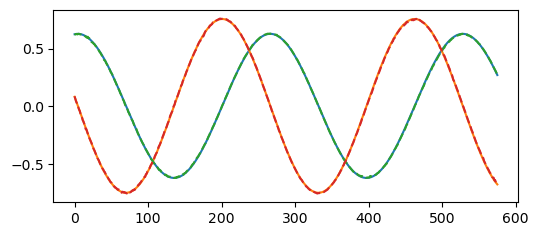

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.053592, valid=0.042498, test=0.043339
	validation loss decreased (inf -> 0.042498), saving model ...
	epoch 2 losses: train=0.041392, valid=0.029720, test=0.030539
	validation loss decreased (0.042498 -> 0.029720), saving model ...
	epoch 3 losses: train=0.025660, valid=0.024182, test=0.024648
	validation loss decreased (0.029720 -> 0.024182), saving model ...
	epoch 4 losses: train=0.024448, valid=0.023923, test=0.024366
	validation loss decreased (0.024182 -> 0.023923), saving model ...
	epoch 5 losses: train=0.023937, valid=0.022985, test=0.023409
	validation loss decreased (0.023923 -> 0.022985), saving model ...
	epoch 6 losses: train=0.021501, valid=0.019290, test=0.019827
	validation loss decreased (0.022985 -> 0.019290), saving model ...
	epoch 7 losses: train=0.018894, valid=0.017919, test=0.018245
	validation loss decreased (0.019290 -> 0.017919), saving model ...
	epoch 8 losses: train=0.017405, valid=0.016966, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

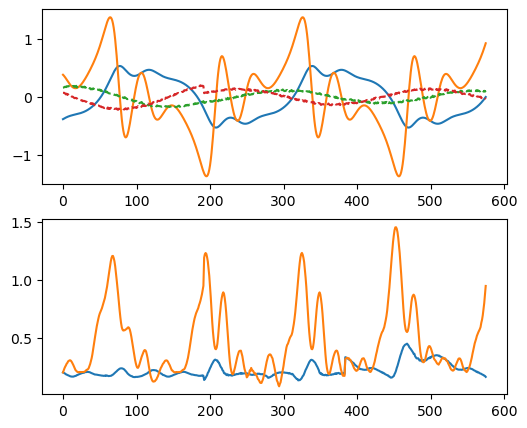

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break


In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.280516, valid=0.246872, test=0.247457
	validation loss decreased (inf -> 0.246872), saving model ...
	epoch 2 losses: train=0.217881, valid=0.178710, test=0.180188
	validation loss decreased (0.246872 -> 0.178710), saving model ...
	epoch 3 losses: train=0.157128, valid=0.107675, test=0.107401
	validation loss decreased (0.178710 -> 0.107675), saving model ...
	epoch 4 losses: train=0.102312, valid=0.097229, test=0.097324
	validation loss decreased (0.107675 -> 0.097229), saving model ...
	epoch 5 losses: train=0.092559, valid=0.082289, test=0.081792
	validation loss decreased (0.097229 -> 0.082289), saving model ...
	epoch 6 losses: train=0.070300, valid=0.059147, test=0.059230
	validation loss decreased (0.082289 -> 0.059147), saving model ...
	epoch 7 losses: train=0.056497, valid=0.049998, test=0.049696
	validation loss decreased (0.059147 -> 0.049998), saving model ...
	epoch 8 losses: train=0.045975, valid=0.037678, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

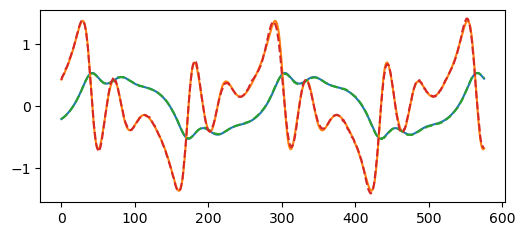

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.059130, valid=0.042060, test=0.042147
	validation loss decreased (inf -> 0.042060), saving model ...
	epoch 2 losses: train=0.035364, valid=0.025452, test=0.025504
	validation loss decreased (0.042060 -> 0.025452), saving model ...
	epoch 3 losses: train=0.024344, valid=0.024309, test=0.024341
	validation loss decreased (0.025452 -> 0.024309), saving model ...
	epoch 4 losses: train=0.024023, valid=0.024064, test=0.024088
	validation loss decreased (0.024309 -> 0.024064), saving model ...
	epoch 5 losses: train=0.023699, valid=0.022492, test=0.022459
	validation loss decreased (0.024064 -> 0.022492), saving model ...
	epoch 6 losses: train=0.021335, valid=0.020721, test=0.020695
	validation loss decreased (0.022492 -> 0.020721), saving model ...
	epoch 7 losses: train=0.020580, valid=0.020018, test=0.019969
	validation loss decreased (0.020721 -> 0.020018), saving model ...
	epoch 8 losses: train=0.019237, valid=0.018903, 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

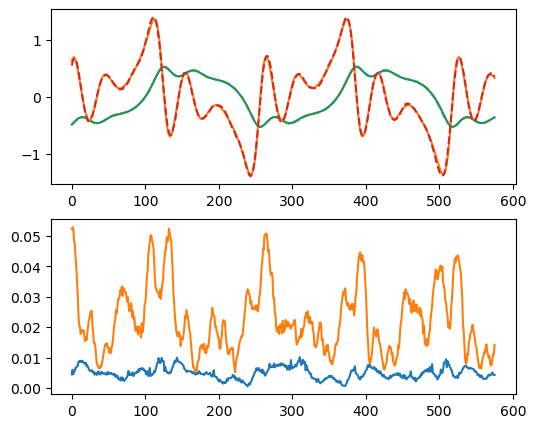

In [15]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

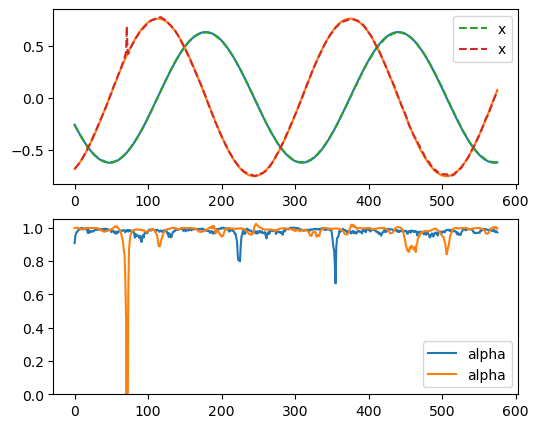

In [20]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break